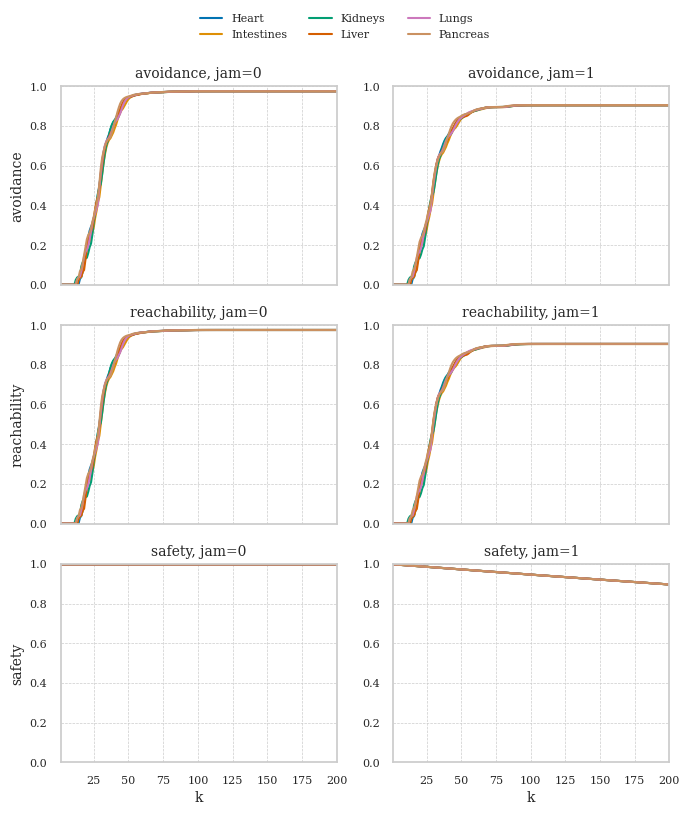

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("bounded_by_k_v2.csv")

# =========================
# 2. VALIDATE / CLEAN
# =========================
required_cols = ["seed", "organ", "jamming", "k",
                 "avoidance", "reachability", "safety"]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df["jamming"] = df["jamming"].astype(int)
df["k"] = pd.to_numeric(df["k"], errors="coerce")
df = df.dropna()

# =========================
# 3. AGGREGATE
# =========================
properties = ["avoidance", "reachability", "safety"]

df_agg = (
    df.groupby(["organ", "jamming", "k"])[properties]
    .mean()
    .reset_index()
    .sort_values("k")
)

organs = sorted(df_agg["organ"].unique())

# =========================
# 4. IEEE-STYLE SETTINGS
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
})

# Use colorblind-friendly palette (also prints well)
palette = sns.color_palette("colorblind", len(organs))
color_map = dict(zip(organs, palette))

# =========================
# 5. CREATE SUBPLOTS
# =========================
fig, axes = plt.subplots(3, 2, figsize=(7, 8), sharex=True)

for row, prop in enumerate(properties):
    for col, jamming_value in enumerate([0, 1]):
        ax = axes[row, col]

        subset = df_agg[df_agg["jamming"] == jamming_value]

        for organ in organs:
            organ_data = subset[subset["organ"] == organ]

            ax.plot(
                organ_data["k"],
                organ_data[prop],
                label=organ,
                color=color_map[organ]
            )

        # Titles (short, IEEE style)
        ax.set_title(f"{prop}, jam={jamming_value}")

        # Axis labels only on outer edges (cleaner)
        if col == 0:
            ax.set_ylabel(prop)
        if row == 2:
            ax.set_xlabel("k")

        # 🔑 FIXED AXES
        ax.set_ylim(0, 1)
        ax.set_xlim(df_agg["k"].min(), df_agg["k"].max())

# =========================
# 6. LEGEND (COMPACT)
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

# =========================
# 7. FINAL LAYOUT
# =========================
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save as vector (IEEE prefers this)
plt.savefig("ieee_plots.pdf", bbox_inches="tight")
plt.savefig("ieee_plots.png", dpi=300, bbox_inches="tight")

plt.show()

In [104]:
df["avoidance"].describe()

,avoidance
count,48000.000000
mean,0.800009
std,0.325913
min,0.000000
25%,0.834712
50%,0.939712
75%,0.978308
max,1.000000


In [105]:
df

,seed,organ,jamming,k,avoidance,reachability,safety
0,0,Heart,0,1,0.000000,0.000000,0.980000
1,0,Heart,0,2,0.000000,0.000000,0.979600
2,0,Heart,0,3,0.000000,0.000000,0.979592
3,0,Heart,0,4,0.000000,0.000000,0.979592
4,0,Heart,0,5,0.000000,0.000000,0.979592
...,...,...,...,...,...,...,...
47995,19,Kidneys,1,196,0.943464,0.943464,0.901465
47996,19,Kidneys,1,197,0.943464,0.943464,0.900991
47997,19,Kidneys,1,198,0.943464,0.943464,0.900500
47998,19,Kidneys,1,199,0.943464,0.943464,0.900026


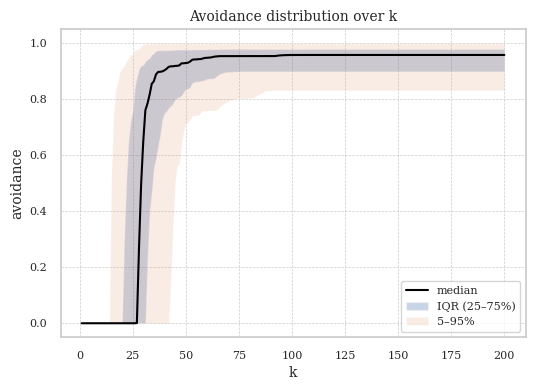

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. GROUP BY k
# =========================
g = df.groupby("k")["avoidance"]

summary = pd.DataFrame({
    "median": g.quantile(0.5),
    "q25": g.quantile(0.25),
    "q75": g.quantile(0.75),
    "q05": g.quantile(0.05),
    "q95": g.quantile(0.95),
    "min": g.min(),
    "max": g.max()
}).sort_index()

# =========================
# 2. PLOT
# =========================
plt.figure(figsize=(6, 4))

x = summary.index

# main line (like mean/median in describe)
plt.plot(x, summary["median"], label="median", color="black")

# IQR band (like spread in describe)
plt.fill_between(
    x,
    summary["q25"],
    summary["q75"],
    alpha=0.3,
    label="IQR (25–75%)"
)

# wider uncertainty band
plt.fill_between(
    x,
    summary["q05"],
    summary["q95"],
    alpha=0.15,
    label="5–95%"
)

plt.xlabel("k")
plt.ylabel("avoidance")
plt.title("Avoidance distribution over k")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

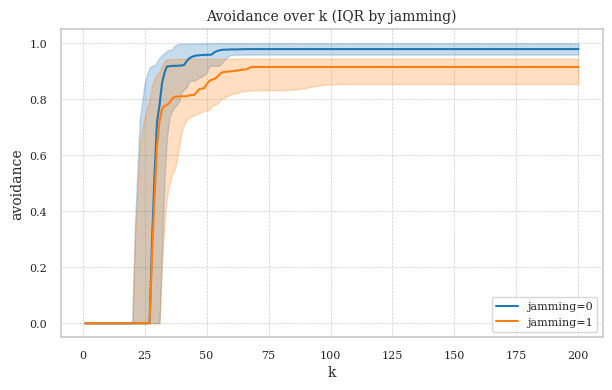

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. GROUP BY k + jamming
# =========================
df_filtered = df

g = df_filtered.groupby(["k", "jamming"])["avoidance"]

summary = g.agg(
    median=lambda x: x.quantile(0.5),
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
).reset_index()

# =========================
# 2. PLOT
# =========================
plt.figure(figsize=(7, 4))

colors = {0: "tab:blue", 1: "tab:orange"}

for j in [0, 1]:
    sub = summary[summary["jamming"] == j].sort_values("k")
    x = sub["k"]

    # median line
    plt.plot(
        x,
        sub["median"],
        label=f"jamming={j}",
        color=colors[j]
    )

    # IQR band
    plt.fill_between(
        x,
        sub["q25"],
        sub["q75"],
        color=colors[j],
        alpha=0.25
    )

plt.xlabel("k")
plt.ylabel("avoidance")
plt.title("Avoidance over k (IQR by jamming)")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

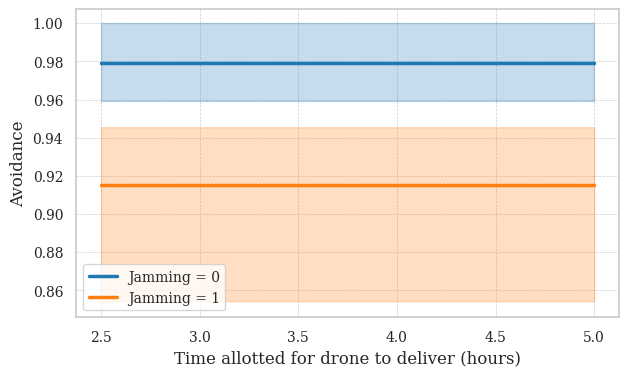

In [142]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# GLOBAL FONT SETTINGS
# -------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

# =========================
# 1. FILTER + SCALE k
# =========================
df_filtered = df[df["k"] >= 100].copy()
df_filtered["k"] = df_filtered["k"] / 40  # time in hours

# =========================
# 2. GROUP
# =========================
g = df_filtered.groupby(["k", "jamming"])["avoidance"]

summary = g.agg(
    median=lambda x: x.quantile(0.5),
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
).reset_index()

# =========================
# 3. PLOT
# =========================
plt.figure(figsize=(7, 4))

colors = {0: "tab:blue", 1: "tab:orange"}

for j in [0, 1]:
    sub = summary[summary["jamming"] == j].sort_values("k")
    x = sub["k"]

    plt.plot(
        x,
        sub["median"],
        label=f"Jamming = {j}",
        color=colors[j],
        linewidth=2.5
    )

    plt.fill_between(
        x,
        sub["q25"],
        sub["q75"],
        color=colors[j],
        alpha=0.25
    )

plt.xlabel("Time allotted for drone to deliver (hours)")
plt.ylabel("Avoidance")

plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

In [108]:
df.groupby(["organ"]).head()

,seed,organ,jamming,k,avoidance,reachability,safety
0,0,Heart,0,1,0.0,0.0,0.980000
1,0,Heart,0,2,0.0,0.0,0.979600
2,0,Heart,0,3,0.0,0.0,0.979592
3,0,Heart,0,4,0.0,0.0,0.979592
4,0,Heart,0,5,0.0,0.0,0.979592
200,0,Lungs,0,1,0.0,0.0,0.980000
201,0,Lungs,0,2,0.0,0.0,0.979600
202,0,Lungs,0,3,0.0,0.0,0.979592
203,0,Lungs,0,4,0.0,0.0,0.979592
204,0,Lungs,0,5,0.0,0.0,0.979592


In [109]:
import numpy as np
import pandas as pd

# group into distributions
dist = df.groupby(["organ", "jamming", "k"])["avoidance"].apply(list).reset_index()

def sample_avoidance(df_dist, organ, jamming, k, seed=None):
    row = df_dist[
        (df_dist["organ"] == organ) &
        (df_dist["jamming"] == jamming) &
        (df_dist["k"] == k)
    ]
    # print(row)
    if row.empty:
        raise ValueError("No data for this (organ, jamming, k) combination")

    values = row["avoidance"].values

    # print(row["avoidance"])

    return rng.choice(values)

In [115]:
import numpy as np
import pandas as pd
import math

# -------------------------
# parameters
# -------------------------
n_seeds = 100
steps_per_hr = 40
mean = 4.5*steps_per_hr  # Exp(36)

organs = ["Heart", "Lungs", "Intestines", "Liver", "Pancreas", "Kidneys"]
expiry = [4, 4, 6, 8, 12, 24]
expiry = [e * steps_per_hr for e in expiry]

# -------------------------
# simulation
# -------------------------
rows = []

for seed in range(n_seeds):
    np.random.seed(seed)

    # draw one exponential variable per seed
    event_time = np.random.exponential(scale=mean)

    rng = np.random.default_rng(seed)


    for organ, t_exp in zip(organs, expiry):
        # print(df.head())
        k = math.floor(t_exp - event_time)
        # print(k)
        if k > 200:
            jamming_success_rate = sample_avoidance(df, organ, 1, 200, rng)
            no_jam_success_rate = sample_avoidance(df, organ, 0, 200, rng)
        elif k > 0:
            # print(k)
            jamming_success_rate = sample_avoidance(df, organ, 1, k, rng)
            no_jam_success_rate = sample_avoidance(df, organ, 0, k, rng)
        else:
            jamming_success_rate = 0
            no_jam_success_rate = 0

        rows.append({
            "seed": seed,
            "organ": organ,
            "initial_time_loss": event_time,
            "expiration_time": t_exp,
            "time_left_for_drone": k,
            "jamming_success_rate": jamming_success_rate,
            "no_jam_success_rate": no_jam_success_rate,
            "expired": event_time > t_exp
        })

df_final_stats = pd.DataFrame(rows)

df_final_stats

,seed,organ,initial_time_loss,expiration_time,time_left_for_drone,jamming_success_rate,no_jam_success_rate,expired
0,0,Heart,143.257411,160,16,0.000000e+00,0.000000,False
1,0,Lungs,143.257411,160,16,3.294132e-07,0.000000,False
2,0,Intestines,143.257411,240,96,8.310218e-01,0.977519,False
3,0,Liver,143.257411,320,176,8.653791e-01,0.977521,False
4,0,Pancreas,143.257411,480,336,9.741104e-01,0.998351,False
...,...,...,...,...,...,...,...,...
595,99,Lungs,200.806433,160,-41,0.000000e+00,0.000000,True
596,99,Intestines,200.806433,240,39,5.513663e-26,0.920444,False
597,99,Liver,200.806433,320,119,9.397123e-01,1.000000,False
598,99,Pancreas,200.806433,480,279,9.741104e-01,0.979592,False


In [116]:
df_final_stats["delta_success"] = df_final_stats["jamming_success_rate"] - df_final_stats["no_jam_success_rate"]

df_final_stats["realized_success_jam"] = (1 - df_final_stats["expired"]) * df_final_stats["jamming_success_rate"]
df_final_stats["realized_success_nojam"] = (1 - df_final_stats["expired"]) * df_final_stats["no_jam_success_rate"]

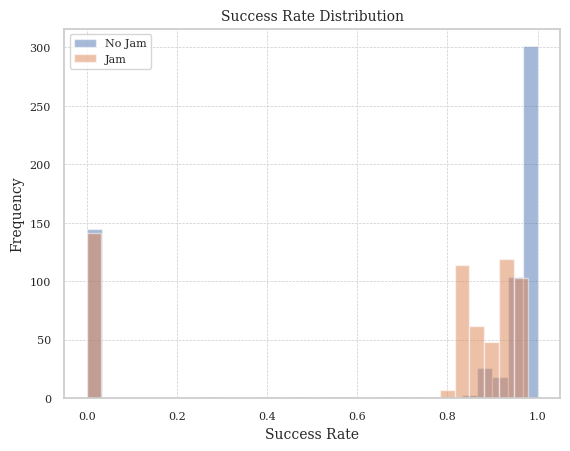

In [117]:
import matplotlib.pyplot as plt

plt.hist(df_final_stats["no_jam_success_rate"], bins=30, alpha=0.5, label="No Jam")
plt.hist(df_final_stats["jamming_success_rate"], bins=30, alpha=0.5, label="Jam")

plt.xlabel("Success Rate")
plt.ylabel("Frequency")
plt.title("Success Rate Distribution")
plt.legend()
plt.show()

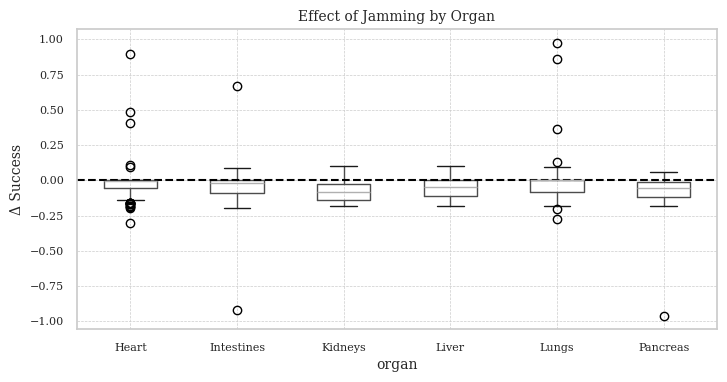

In [118]:
df_final_stats.boxplot(column="delta_success", by="organ", figsize=(8, 4))

plt.axhline(0, linestyle="--", color="black")
plt.title("Effect of Jamming by Organ")
plt.suptitle("")
plt.ylabel("Δ Success")

plt.show()

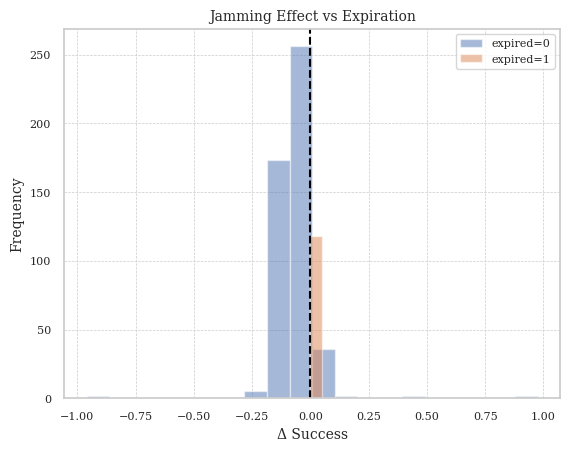

In [119]:
for exp in [0, 1]:
    subset = df_final_stats[df_final_stats["expired"] == exp]
    plt.hist(subset["delta_success"], bins=20, alpha=0.5, label=f"expired={exp}")

plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Δ Success")
plt.ylabel("Frequency")
plt.title("Jamming Effect vs Expiration")
plt.legend()
plt.show()

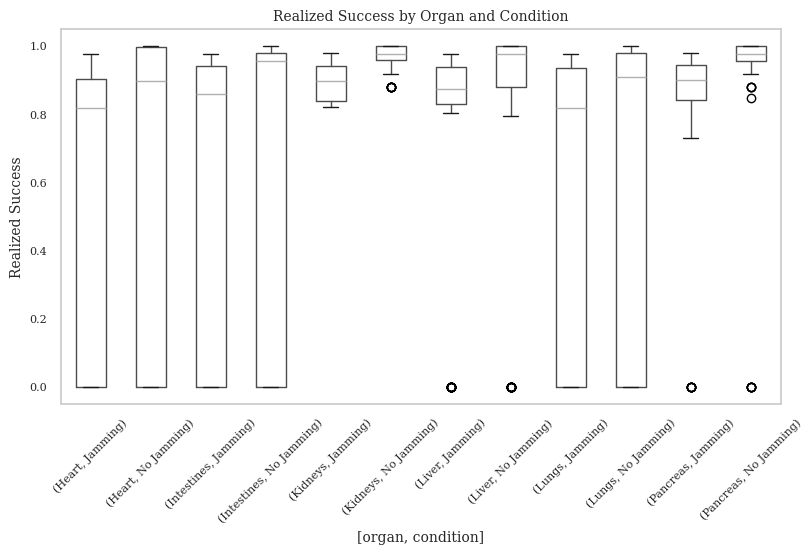

In [120]:
import matplotlib.pyplot as plt
df_long = pd.melt(
    df_final_stats,
    id_vars=["organ"],
    value_vars=["realized_success_jam", "realized_success_nojam"],
    var_name="condition",
    value_name="realized_success"
)

df_long["condition"] = df_long["condition"].map({
    "realized_success_jam": "Jamming",
    "realized_success_nojam": "No Jamming"
})
fig, ax = plt.subplots(figsize=(9, 5))

df_long.boxplot(
    column="realized_success",
    by=["organ", "condition"],
    ax=ax,
    grid=False
)

plt.title("Realized Success by Organ and Condition")
plt.suptitle("")
plt.ylabel("Realized Success")
plt.xticks(rotation=45)

plt.show()

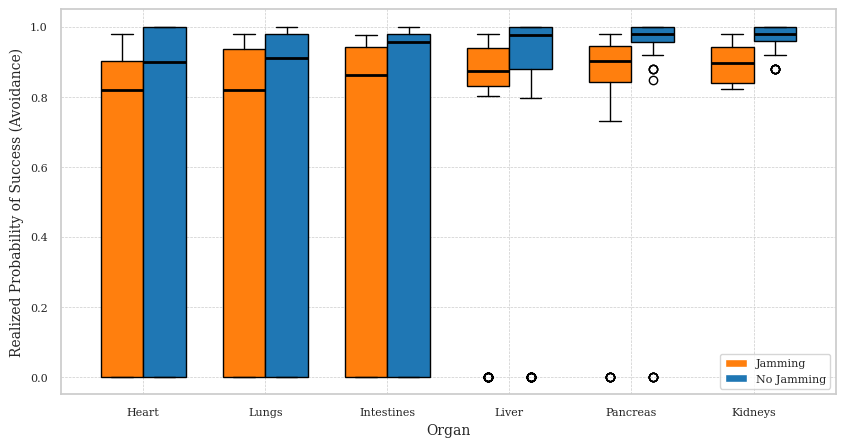

In [127]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

organs = df_long["organ"].unique()

data_jam = []
data_nojam = []

for organ in organs:
    data_jam.append(
        df_long[
            (df_long["organ"] == organ) &
            (df_long["condition"] == "Jamming")
        ]["realized_success"]
    )

    data_nojam.append(
        df_long[
            (df_long["organ"] == organ) &
            (df_long["condition"] == "No Jamming")
        ]["realized_success"]
    )

x = np.arange(len(organs))
width = 0.35

# plot boxes
bp1 = ax.boxplot(
    data_jam,
    positions=x - width/2,
    widths=width,
    patch_artist=True
)

bp2 = ax.boxplot(
    data_nojam,
    positions=x + width/2,
    widths=width,
    patch_artist=True
)

# colors
for box in bp1["boxes"]:
    box.set(facecolor="tab:orange")

for box in bp2["boxes"]:
    box.set(facecolor="tab:blue")
# make medians black and thicker
for median in bp1["medians"]:
    median.set(color="black", linewidth=2)

for median in bp2["medians"]:
    median.set(color="black", linewidth=2)
# axis formatting
ax.set_xticks(x)
ax.set_xticklabels(organs)
ax.set_ylabel("Realized Probability of Success (Avoidance)")
ax.set_xlabel("Organ")
# ax.set_title("Realized Success by Organ (Jam vs No Jam)")

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tab:orange", label="Jamming"),
    Patch(facecolor="tab:blue", label="No Jamming")
]
ax.legend(handles=legend_elements)

plt.show()

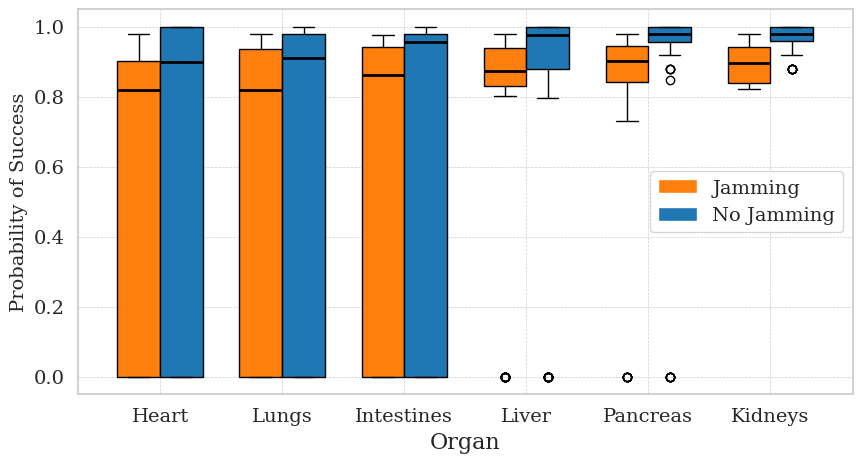

In [145]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

organs = df_long["organ"].unique()

data_jam = []
data_nojam = []

for organ in organs:
    data_jam.append(
        df_long[
            (df_long["organ"] == organ) &
            (df_long["condition"] == "Jamming")
        ]["realized_success"]
    )

    data_nojam.append(
        df_long[
            (df_long["organ"] == organ) &
            (df_long["condition"] == "No Jamming")
        ]["realized_success"]
    )

x = np.arange(len(organs))
width = 0.35

bp1 = ax.boxplot(
    data_jam,
    positions=x - width/2,
    widths=width,
    patch_artist=True
)

bp2 = ax.boxplot(
    data_nojam,
    positions=x + width/2,
    widths=width,
    patch_artist=True
)

# colors
for box in bp1["boxes"]:
    box.set(facecolor="tab:orange")

for box in bp2["boxes"]:
    box.set(facecolor="tab:blue")

# medians
for median in bp1["medians"]:
    median.set(color="black", linewidth=2)

for median in bp2["medians"]:
    median.set(color="black", linewidth=2)

# -------------------------
# FONT SIZE INCREASES
# -------------------------
ax.set_xticks(x)
ax.set_xticklabels(organs, fontsize=16)

ax.set_ylabel("Probability of Success", fontsize=14)
ax.set_xlabel("Organ", fontsize=16)

ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tab:orange", label="Jamming"),
    Patch(facecolor="tab:blue", label="No Jamming")
]

ax.legend(handles=legend_elements, fontsize=14)

plt.show()

In [122]:
df_final_stats["expired"].mean()

np.float64(0.19666666666666666)

In [123]:
df_final_stats.groupby("organ")["expired"].mean() * 100

,expired
organ,
Heart,36.0
Intestines,23.0
Kidneys,0.0
Liver,18.0
Lungs,36.0
Pancreas,5.0
